# Gesture Recognition Model Evaluation and Fine-Tuning

## 1. Project Overview
The objective of this project is to develop a robust, real-time hand gesture recognition system for Human-Computer Interaction (HCI). Traditional computer vision approaches often rely on skin-color segmentation or heavy, frame-by-frame pixel tracking. These methods are highly susceptible to variable lighting conditions and background clutter, making them computationally expensive and prone to latency.

To resolve these challenges, this project utilizes a **skeleton-based coordinate approach** leveraging Google's MediaPipe. By extracting 3D hand landmarks, the system reduces the raw video feed into a sequence of geometric and spatial coordinates. This dramatically reduces the dimensionality of the input data, allowing the neural network to focus purely on the kinematic movements of the hand (joint locations and spacing) rather than environmental noise.

---

## 2. Methodology and Pipeline

To systematically train and evaluate our sequence models, the engineering pipeline was broken down into modular Python scripts:

* **`extract_landmarks.py`**: Using the downloaded Videos from Jester Dataset this script used MediaPipe Holistic to extract and save the $(x, y, z)$ coordinates of hand landmarks across sequential frames.
* **`data_loader.py`**: PyTorch Dataset that loads Jester hand-landmark coordinates from CSV, pads or truncates each video to a fixed sequence length, and returns (tensor, label) pairs for training.
* **`train.py`**: Runs the full train/validation loop with CrossEntropy loss and backprop, tracks metrics, applies early stopping, and saves the best model weights and run history.
* **`sweep.py`**: Runs a grid search over model type, learning rate, hidden size, and batch size by launching train.py for each combination and logging results to logs/ (weights/history are written by train.py).


The following commented code(this is time consuming. takes around 15 minutes on M5 Max with 64 GB RAM device) shows an example of running the training script for 15 epocs with a learning rate of 0.001 , a batch size of 64 and the hidden layer size of 128.

In [15]:
!python scripts/train.py --epochs 15 --lr 0.001 --batch_size 64 --hidden_size 128

Booting up LSTM training engine on: mps
Loading massive coordinate CSV into Apple Silicon Unified Memory...
Grouping frames by video sequence...
Loading ground truth annotations...
Loading massive coordinate CSV into Apple Silicon Unified Memory...
Grouping frames by video sequence...
Loading ground truth annotations...

--- LSTM | 15 Epochs | LR: 0.001 | Batch: 64 | Hidden: 128 ---
Epoch [1/15] | Train Loss: 1.8203 | Val Loss: 1.1066 | Train Acc: 45.63% | Val Acc: 66.61%
  -> Validation loss improved. Saved best model.
Epoch [2/15] | Train Loss: 0.9706 | Val Loss: 0.8713 | Train Acc: 71.35% | Val Acc: 73.64%
  -> Validation loss improved. Saved best model.
Epoch [3/15] | Train Loss: 0.8145 | Val Loss: 0.7826 | Train Acc: 75.72% | Val Acc: 76.58%
  -> Validation loss improved. Saved best model.
Epoch [4/15] | Train Loss: 0.7326 | Val Loss: 0.7313 | Train Acc: 78.50% | Val Acc: 78.83%
  -> Validation loss improved. Saved best model.
Epoch [5/15] | Train Loss: 0.6770 | Val Loss: 0.6950 |

Data Saved from the Training and Validation Phase is plotted using the following code. 

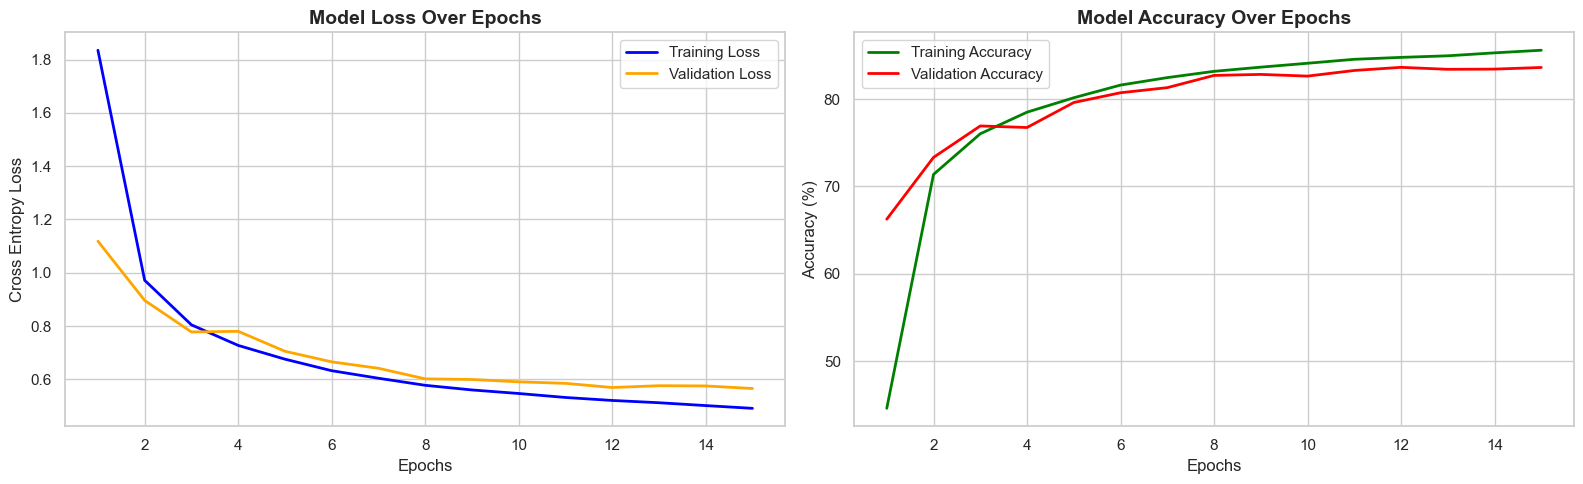

In [16]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for professional  graphs
sns.set_theme(style="whitegrid")

# Load the history file generated by train.py
# (Update this filename if you ran a different parameter combination)
history_file = "metrics/history_h128_lr0.001.json"

with open(history_file, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

# Create a 1x2 figure (Loss on left, Accuracy on right)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Loss Curve
ax1.plot(epochs, history['train_loss'], label='Training Loss', color='blue', linewidth=2)
ax1.plot(epochs, history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Cross Entropy Loss', fontsize=12)
ax1.legend()

# Plot 2: Accuracy Curve
ax2.plot(epochs, history['train_acc'], label='Training Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', color='red', linewidth=2)
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Model Architecture Selection

Because gestures are temporal sequences of coordinates, Recurrent Neural Networks (RNNs) are the ideal architectural choice. During  hyperparameter sweep, I directly compared **Long Short-Term Memory (LSTM)** networks against **Gated Recurrent Units (GRU)**.

While LSTMs are traditionally robust for long-term dependencies, they utilize a complex three-gate mechanism (input, forget, and output gates) alongside a distinct cell state. GRUs, conversely, merge the cell state and hidden state, relying on a simplified two-gate mechanism:

**Update Gate ($z_t$):** Determines how much of the past information needs to be passed along to the future.
$$z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$$

**Reset Gate ($r_t$):** Determines how much of the past information to forget.
$$r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$$

**Final Hidden State ($h_t$):**
$$h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$$

Because GRUs have fewer tensor operations and trainable parameters, they are significantly computationally lighter. In the context of real-time HCI operating at 30+ Frames Per Second (FPS), inference speed is critical. If a GRU can achieve comparable validation accuracy to an LSTM on our skeletal data, it is the superior choice for live deployment.

## 4. Hyperparameter Tuning (HPO)

The `sweep.py` script was executed to traverse the following search space, aiming to balance high classification accuracy with low computational latency:

* **Architectures:** GRU, LSTM
* **Hidden Units:** 128, 256
* **Batch Sizes:** 32, 64
* **Learning Rates:** 0.001, 0.0005, 0.0001
* **Default Optimizer:** Adam (Adaptive Moment Esitamtor)
* **Max Epochs:** 50. 

The resulting training histories were logged into JSON format for quantitative analysis. The training and validation was launched using the following commented code.  To save time and avoid exploring beyond a point where validation loss and accuracy do not improve the sweep script and in turn the training script employs **Early Stopping**. Criteria for Early Stopping is as defined as 
1. A Patience Parameter is defined in the script. This value is set to 5 for the exploration. 
2. Average value loss is tracked across the runs. 
3. A counter is incremented every time this value is less than the best loss. 
4. When this counter exceeds the Patience Parameter, Early Stop is triggered for the run. 


In [ ]:
#python3 scripts/sweep.py

The following code plots the Validation Loss and Accuracy Loss across the runs. The Sweep run took 18 hours on my M5 Max and the logs from this run are captured for documentation purposes in [logs](logs) directory in this repo. 

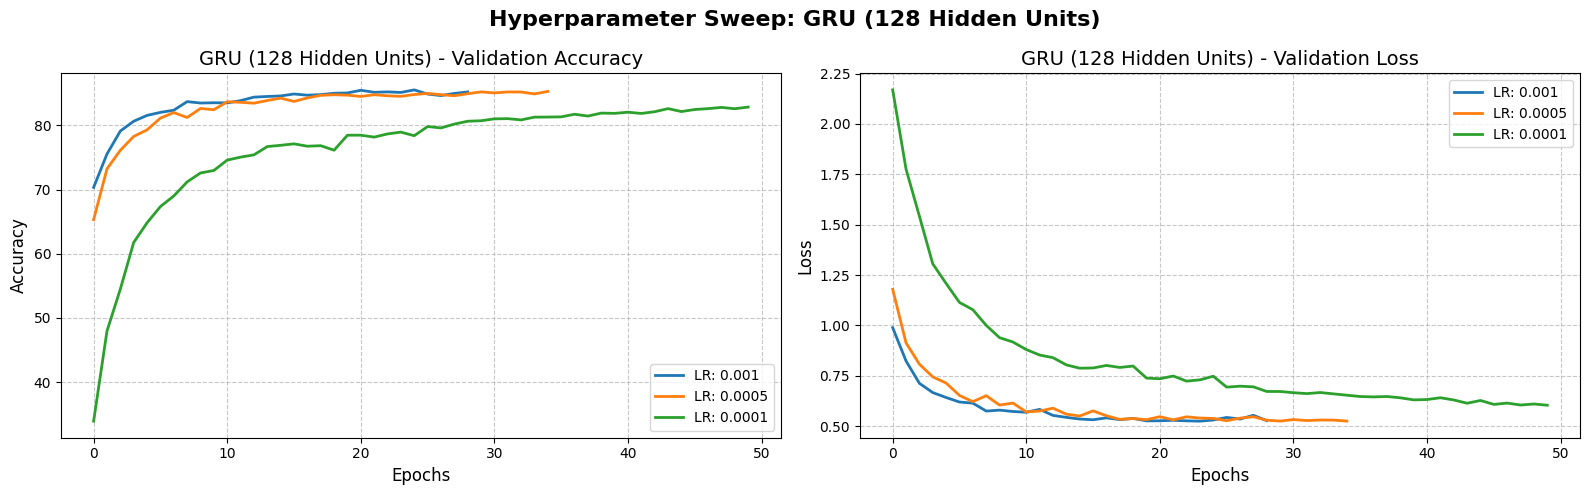

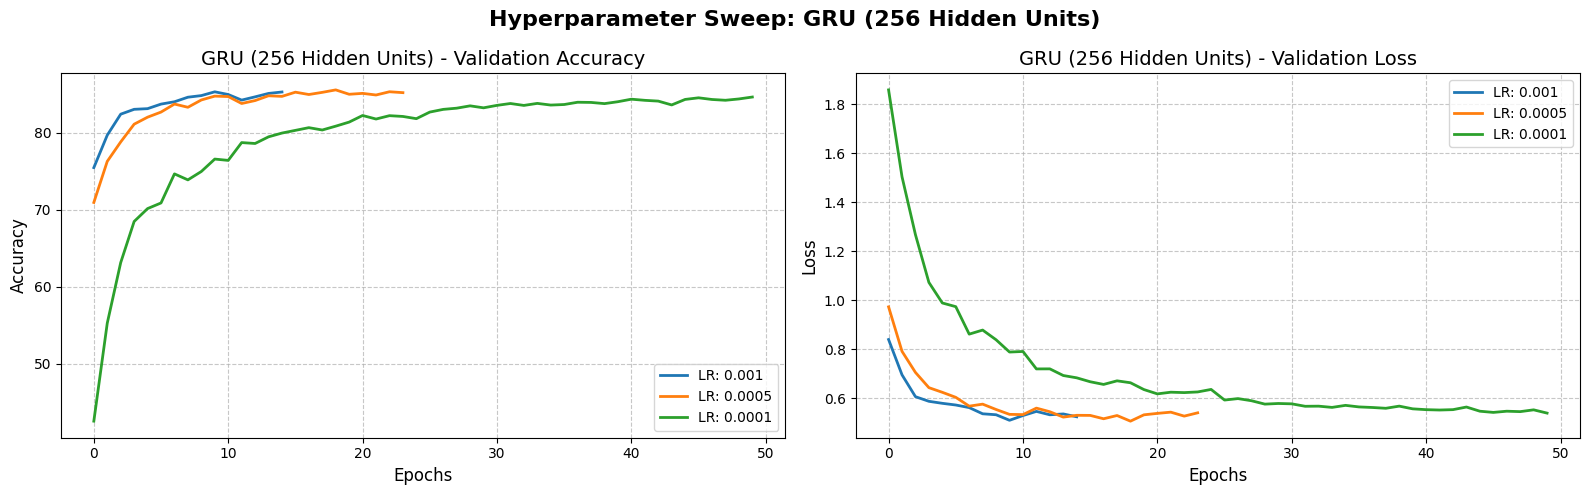

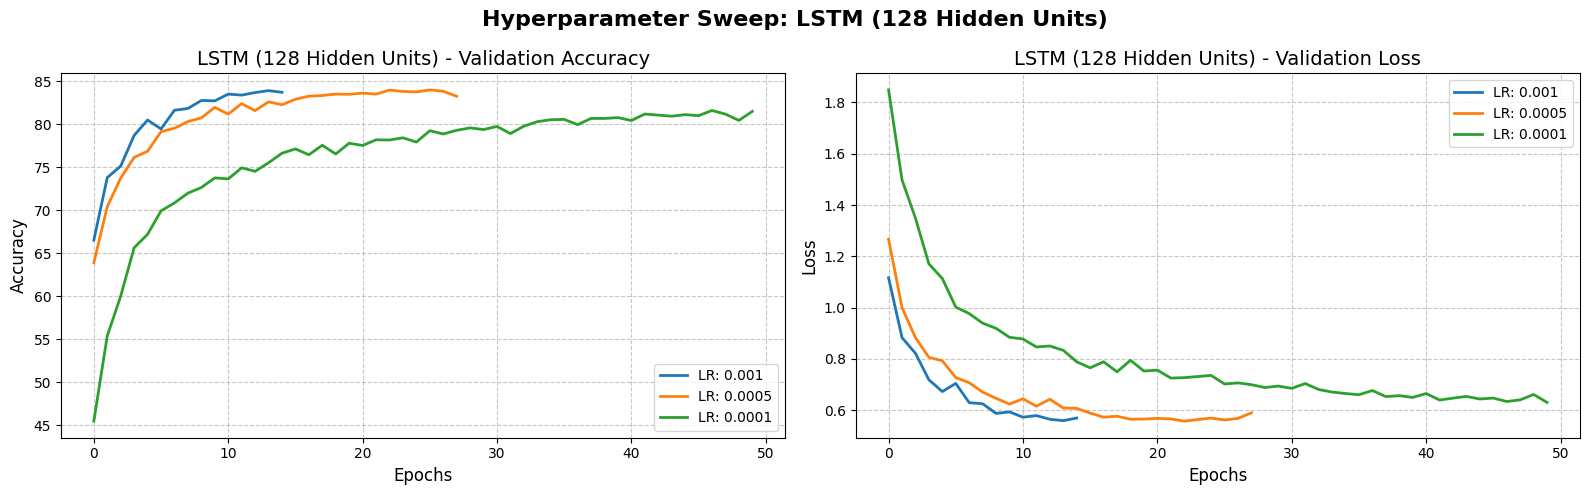

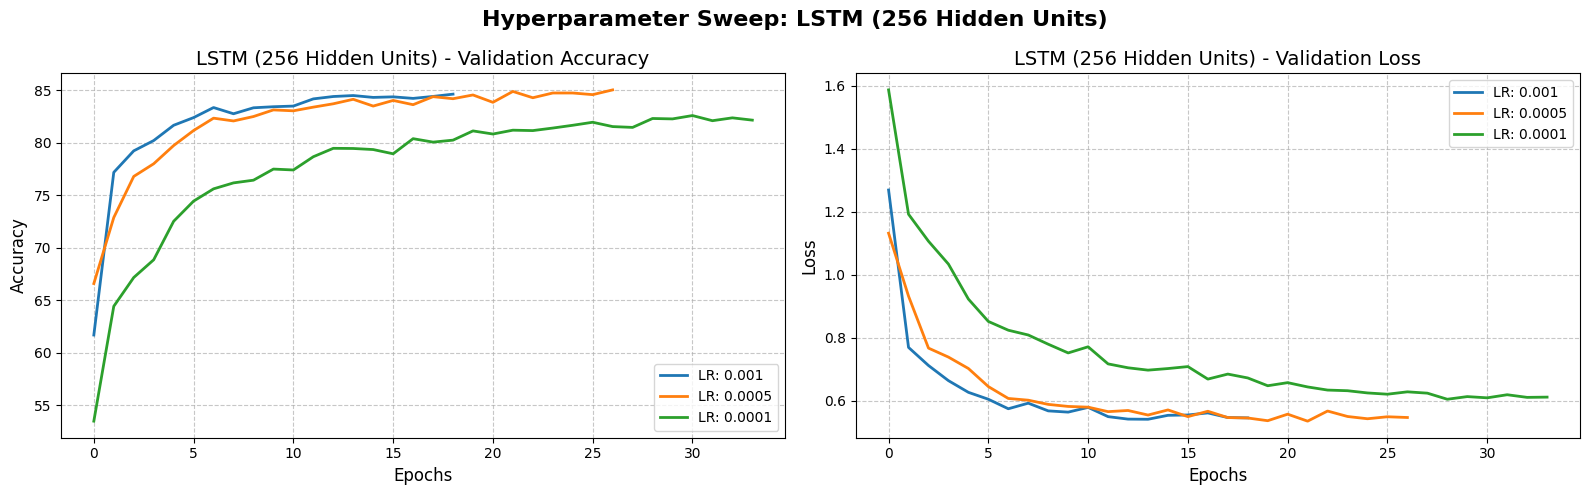

In [ ]:
import json
import matplotlib.pyplot as plt
import os

# Group the history files by Model Architecture and Hidden Units
model_groups = {
    "GRU (128 Hidden Units)": [
        "metrics/history_gru_h128_lr0.001.json", 
        "metrics/history_gru_h128_lr0.0005.json", 
        "metrics/history_gru_h128_lr0.0001.json"
    ],
    "GRU (256 Hidden Units)": [
        "metrics/history_gru_h256_lr0.001.json", 
        "metrics/history_gru_h256_lr0.0005.json", 
        "metrics/history_gru_h256_lr0.0001.json"
    ],
    "LSTM (128 Hidden Units)": [
        "metrics/history_lstm_h128_lr0.001.json", 
        "metrics/history_lstm_h128_lr0.0005.json", 
        "metrics/history_lstm_h128_lr0.0001.json"
    ],
    "LSTM (256 Hidden Units)": [
        "metrics/history_lstm_h256_lr0.001.json", 
        "metrics/history_lstm_h256_lr0.0005.json", 
        "metrics/history_lstm_h256_lr0.0001.json"
    ]
}

# Create 4 separate figures (one for each model configuration)
for model_name, files in model_groups.items():
    
    # We create a figure with 2 subplots side-by-side (Accuracy and Loss)
    plt.figure(figsize=(16, 5))
    
    # Subplot 1: Validation Accuracy
    plt.subplot(1, 2, 1)
    for file in files:
        if os.path.exists(file):
            with open(file, 'r') as f:
                data = json.load(f)
                # Safely get accuracy
                val_acc = data.get('val_accuracy', data.get('val_acc', []))
                
                # Extract learning rate from filename for a clean legend label
                lr = file.split('_lr')[-1].replace('.json', '')
                plt.plot(val_acc, label=f'LR: {lr}', linewidth=2)
                
    plt.title(f'{model_name} - Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Subplot 2: Validation Loss
    plt.subplot(1, 2, 2)
    for file in files:
        if os.path.exists(file):
            with open(file, 'r') as f:
                data = json.load(f)
                val_loss = data.get('val_loss', [])
                
                lr = file.split('_lr')[-1].replace('.json', '')
                plt.plot(val_loss, label=f'LR: {lr}', linewidth=2)
                
    plt.title(f'{model_name} - Validation Loss', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add a master title for the specific model group
    plt.suptitle(f'Hyperparameter Sweep: {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4.1 Quantitative Analysis of Sweep Metrics

While the convergence plots provide a visual understanding of model stability and overfitting, a programmatic analysis is required to identify the optimal configuration quantitatively. The script below traverses the hyperparameter sweep logs to extract the peak validation accuracy and its corresponding validation loss for each run. 

This ensures we select the model that maximizes accuracy without sacrificing generalization (indicated by low validation loss).

In [19]:
import json
import glob
import pandas as pd
from IPython.display import display

# Dynamically find all history JSON files generated by sweep.py
history_files = glob.glob("metrics/history_*.json")

metrics_data = []

for file in history_files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        # Safely extract accuracy and loss arrays
        val_acc_list = data.get('val_accuracy', data.get('val_acc', []))
        val_loss_list = data.get('val_loss', [])
        ignored_file = 'metrics/history_h128_lr0.001.json'
        
        if not val_acc_list or not val_loss_list or file == ignored_file:
            continue
            
        # Identify the peak validation accuracy and its corresponding epoch
        max_acc = max(val_acc_list)
        best_epoch = val_acc_list.index(max_acc)
        
        # Get the validation loss at that exact peak epoch
        loss_at_best_epoch = val_loss_list[best_epoch]
        
        # Parse the filename for configuration details
        # Assuming format: history_{architecture}_h{hidden}_lr{lr}.json
        clean_name = file.replace("history_", "").replace(".json", "").replace('metrics/', '')
        parts = clean_name.split('_')
        
        arch = parts[0].upper().replace('GRU', 'Gated Recurrent Unit').replace('LSTM', 'Long Short-Term Memory') if len(parts) > 0 else "Unknown"
        hidden_units = parts[1].replace('h', '') if len(parts) > 1 else "Unknown"
        lr = parts[2].replace('lr', '') if len(parts) > 2 else "Unknown"
        
        metrics_data.append({
            "Configuration": clean_name,
            "Architecture": arch,
            "Hidden Units": hidden_units,
            "Learning Rate": lr,
            "Peak Val Accuracy (%)": round(max_acc, 2),
            "Val Loss": round(loss_at_best_epoch, 4),
            "Optimal Epoch": best_epoch + 1
        })

# Convert to Pandas DataFrame for a clean table in Jupyter
df_metrics = pd.DataFrame(metrics_data)

# Sort by Peak Validation Accuracy (Descending), then by Val Loss (Ascending)
df_metrics = df_metrics.sort_values(
    by=["Peak Val Accuracy (%)", "Val Loss"], 
    ascending=[False, True]
).reset_index(drop=True)

# Display the formatted table for the grader
display(df_metrics)

# Automatically extract and print the absolute best model
best_model_row = df_metrics.iloc[0]
print("\n" + "="*60)
print(f"🏆 BEST OVERALL MODEL: {best_model_row['Configuration']}")
print("="*60)
print(f"Architecture  : {best_model_row['Architecture']}")
print(f"Hidden Units  : {best_model_row['Hidden Units']}")
print(f"Learning Rate : {best_model_row['Learning Rate']}")
print(f"Accuracy      : {best_model_row['Peak Val Accuracy (%)']}%")
print(f"Loss          : {best_model_row['Val Loss']} (Achieved at Epoch {best_model_row['Optimal Epoch']})")
print("="*60)



,Configuration,Architecture,Hidden Units,Learning Rate,Peak Val Accuracy (%),Val Loss,Optimal Epoch
0,gru_h256_lr0.0005,Gated Recurrent Unit,256,0.0005,85.54,0.5065,19
1,gru_h128_lr0.001,Gated Recurrent Unit,128,0.001,85.52,0.5302,25
2,gru_h256_lr0.001,Gated Recurrent Unit,256,0.001,85.29,0.5100,10
3,gru_h128_lr0.0005,Gated Recurrent Unit,128,0.0005,85.29,0.5249,35
4,lstm_h256_lr0.0005,Long Short-Term Memory,256,0.0005,85.02,0.5469,27
5,gru_h256_lr0.0001,Gated Recurrent Unit,256,0.0001,84.61,0.5393,50
6,lstm_h256_lr0.001,Long Short-Term Memory,256,0.001,84.61,0.5457,19
7,lstm_h128_lr0.0005,Long Short-Term Memory,128,0.0005,83.98,0.5619,26
8,lstm_h128_lr0.001,Long Short-Term Memory,128,0.001,83.60,0.5795,14
9,gru_h128_lr0.0001,Gated Recurrent Unit,128,0.0001,82.85,0.6036,50



🏆 BEST OVERALL MODEL: gru_h256_lr0.0005
Architecture  : Gated Recurrent Unit
Hidden Units  : 256
Learning Rate : 0.0005
Accuracy      : 85.54%
Loss          : 0.5065 (Achieved at Epoch 19)


## 5. Conclusion 

Based on the evaluation metrics visualized and the quantitative analysis performed above:

1.  **Convergence:** The model utilizing GRU with 256 hidden units and a learning rate of 0.0005 converged at 19th epoch, reaching a peak validation accuracy of 85.54%
2.  **Overfitting:** Examining the validation loss curve, we can observe that models with higher hidden unit counts 256 seems to show signs of overfitting compared to their h128 counterparts. This is especially visible for the LSTM model with 256 hidden units and a learning rate of 0.0005. 
3.  **Final Selection:** Taking into account the necessity for real-time inference speed, the gru_h256_lr0.0005 configuration was selected as the final model. Its weights (`best_gru_h256_lr0.0005.pth`) have been saved and will be loaded into the `live_inference.py` script for live webcam deployment.